      Segment  Country    Product Discount Band  Units Sold  \
0  Government  Germany  Carretera           NaN      1513.0   
1  Government  Germany      Paseo           NaN      1006.0   
2  Government   Canada      Paseo           NaN      1725.0   
3  Government  Germany      Paseo           NaN      1513.0   
4  Government  Germany       Velo           NaN      1006.0   

   Manufacturing Price  Sale Price  Gross Sales  Discounts     Sales  \
0                    3         350     529550.0        0.0  529550.0   
1                   10         350     352100.0        0.0  352100.0   
2                   10         350     603750.0        0.0  603750.0   
3                   10         350     529550.0        0.0  529550.0   
4                  120         350     352100.0        0.0  352100.0   

       COGS    Profit      Date  Month Number Month Name  Year  
0  393380.0  136170.0  1-Dec-14            12   December  2014  
1  261560.0   90540.0  1-Jun-14             6       June  

/tmp/ipykernel_2900/1284226929.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


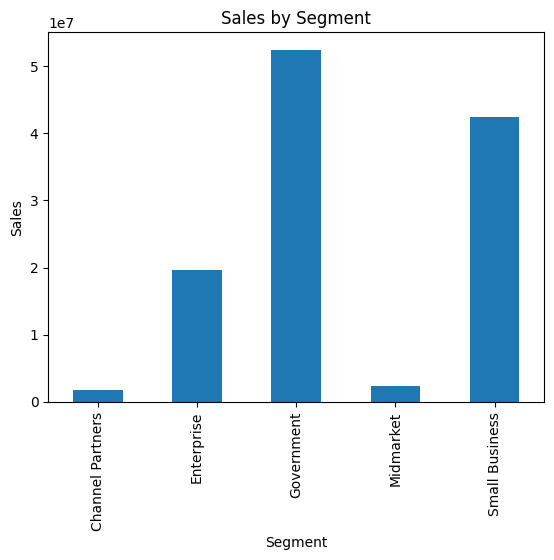


Sales by Country:
Country
Canada                      2.488765e+07
France                      2.435417e+07
Germany                     2.350534e+07
Mexico                      2.094935e+07
United States of America    2.502983e+07
Name: Sales, dtype: float64


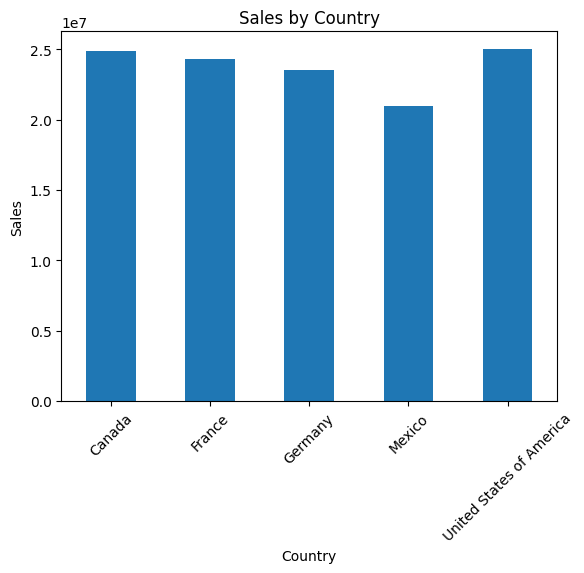


Sales by Product:
Product
Amarilla     1.774712e+07
Carretera    1.381531e+07
Montana      1.539080e+07
Paseo        3.301114e+07
VTT          2.051192e+07
Velo         1.825006e+07
Name: Sales, dtype: float64


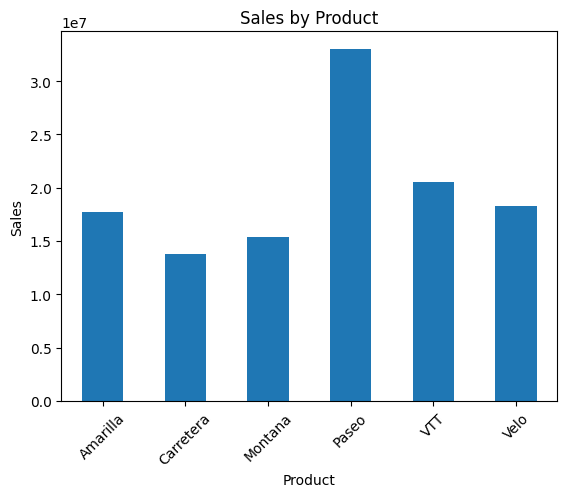


Sales by Year:
Year
2013    26415255.51
2014    92311094.75
Name: Sales, dtype: float64


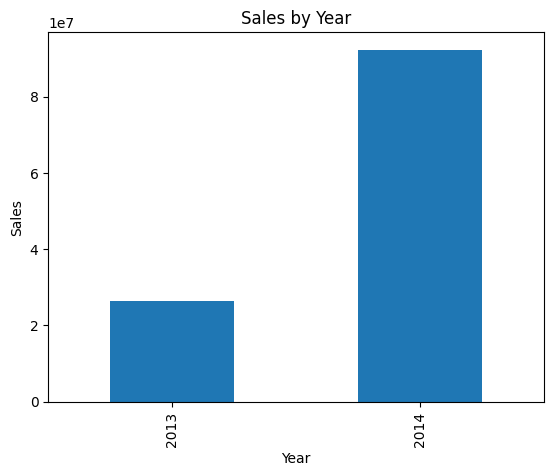


Monthly Sales:
Month Number
1      6607761.68
2      7297531.39
3      5586859.87
4      6964775.07
5      6210211.06
6      9518893.82
7      8102920.18
8      5864622.42
9     10882697.27
10    21671431.02
11    12651417.50
12    17367228.98
Name: Sales, dtype: float64


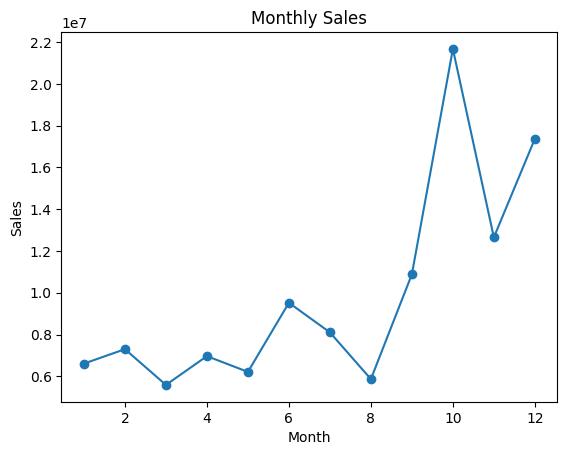


Regression Results:
MAE: 179595.8530021057
R2 Score: 0.06535567010532006


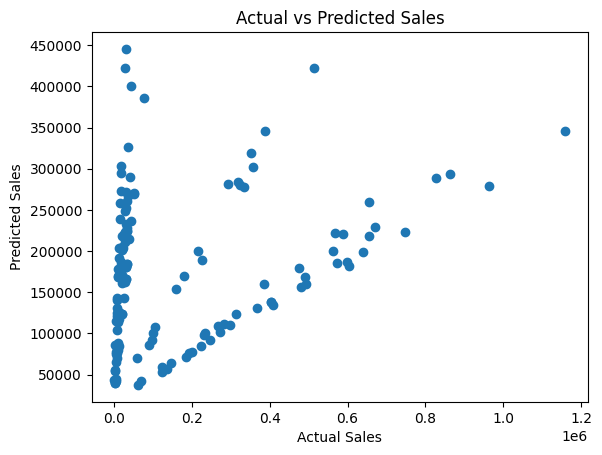

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
df = pd.read_csv("Sample data (1).xlsx - Sheet1.csv")
df.columns = df.columns.str.strip()
print(df.head())
print("\nDataset Shape:")
print(df.shape)
print("\nMissing Values:")
print(df.isnull().sum())
df = df.drop_duplicates()
df["Discount Band"] = df["Discount Band"].fillna("None")
df["Date"] = pd.to_datetime(df["Date"])
print("\nCleaned Dataset:")
print(df.head())
print("\nSales by Segment:")
segment = df.groupby("Segment")["Sales"].sum()
print(segment)
segment.plot(kind="bar")
plt.title("Sales by Segment")
plt.xlabel("Segment")
plt.ylabel("Sales")
plt.show()
print("\nSales by Country:")
country = df.groupby("Country")["Sales"].sum()
print(country)
country.plot(kind="bar")
plt.title("Sales by Country")
plt.xlabel("Country")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()
print("\nSales by Product:")
product = df.groupby("Product")["Sales"].sum()
print(product)
product.plot(kind="bar")
plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()
print("\nSales by Year:")
year = df.groupby("Year")["Sales"].sum()
print(year)
year.plot(kind="bar")
plt.title("Sales by Year")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()
print("\nMonthly Sales:")
month = df.groupby("Month Number")["Sales"].sum()
print(month)
month.plot(kind="line", marker="o")
plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()
X = df[["Units Sold"]]
y = df["Sales"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
prediction = model.predict(X_test)
print("\nRegression Results:")
print("MAE:", mean_absolute_error(y_test, prediction))
print("R2 Score:", r2_score(y_test, prediction))
plt.scatter(y_test, prediction)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()
df.to_csv("cleaned_sales.csv", index=False)